# XGBoost

> CatBoost (bonus, if time permits)

Import the required libraries

In [1]:
%%time

import sys

import pandas as pd
import sklearn
import xgboost
from sklearn.metrics import accuracy_score, auc, classification_report, confusion_matrix, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBClassifier

__VERSIONS: list[str] = [
    f"python={sys.version.split()[0]}",
    f"pandas={pd.__version__}",
    f"scikit-learn={sklearn.__version__}",
    f"xgboost={xgboost.__version__}",
]
__REQUIREMENTS_TXT: str = "\n".join(__VERSIONS)

del sklearn
del xgboost

print(__REQUIREMENTS_TXT, "\n")

python=3.13.9
pandas=2.3.3
scikit-learn=1.7.2
xgboost=3.0.5 

CPU times: total: 1.47 s
Wall time: 10.6 s


In [2]:
import model_pipelines as mp

Define the variables

In [3]:
TARGET = "readmitted"
IDENTIFIERS = ["encounter_id", "patient_nbr"]

Skip the preprocessing (done in WS's notbook)

In [4]:
data = pd.read_csv("preprocessed_data.csv")
for k in data.select_dtypes(include=["object"]):
    data[k] = data[k].astype("category")

In [5]:
data

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,time_in_hospital,num_lab_procedures,num_procedures,...,metformin,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,change,diabetesMed,readmitted
0,24437208,135,Caucasian,Female,[50-60),2,1,8,77,6,...,Steady,No,No,Change,No,No,Steady,Ch,Yes,1
1,29758806,378,Caucasian,Female,[50-60),3,1,2,49,1,...,No,No,No,No,No,No,No,No,No,0
2,189899286,729,Caucasian,Female,[80-90),1,3,4,68,2,...,Steady,No,No,No,No,No,No,No,Yes,0
3,64331490,774,Caucasian,Female,[80-90),1,1,3,46,0,...,Steady,No,No,Steady,No,No,No,Ch,Yes,0
4,14824206,927,AfricanAmerican,Female,[30-40),1,1,5,49,0,...,No,Steady,No,No,No,No,No,No,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71510,418513058,189351095,Caucasian,Female,[80-90),1,1,1,73,1,...,No,No,No,No,No,No,No,No,No,0
71511,359719064,189365864,Other,Male,[60-70),1,1,3,56,1,...,No,No,No,No,No,No,Steady,No,Yes,0
71512,338462954,189445127,Caucasian,Female,[80-90),1,1,3,39,0,...,Steady,No,Change,No,No,Steady,Change,Ch,Yes,0
71513,443811536,189481478,Caucasian,Female,[40-50),1,4,14,69,0,...,Change,No,No,Steady,No,No,Change,Ch,Yes,0


In [6]:
features = [col for col in data.columns if col not in IDENTIFIERS + [TARGET]]
X_train, X_test, y_train, y_test = mp.stratified_split(data, features=features, target=TARGET)

In [7]:
def get_pos_weight(y_train: pd.Series) -> float:
    vc = y_train.value_counts()
    return float(vc[0] / vc[1])

pos_weight = get_pos_weight(y_train)
print(f"{pos_weight = }")

pos_weight = 10.364358683314416


In [8]:
def make_xgb(**kwargs) -> XGBClassifier:
    return XGBClassifier(random_state=42, enable_categorical=True, verbosity=1, **kwargs)

def make_balanced_xgb(**kwargs) -> XGBClassifier:
    return XGBClassifier(random_state=42, scale_pos_weight=pos_weight, enable_categorical=True, verbosity=1, **kwargs)

# `eval_metric`: No difference between logloss, aucpr, and auc.

xgbs = {
    "unbalanced": make_xgb(),
    # "balanced": make_balanced_xgb(),
    # "balanced_maxdepth10": make_balanced_xgb(max_depth=10),
    # "balanced_nestimators300": make_balanced_xgb(n_estimators=300),
    # "balanced_regalpha5": make_balanced_xgb(reg_alpha=5),
    # "balanced_reglambda5": make_balanced_xgb(reg_lambda=5),
    # "balanced_regboth5": make_balanced_xgb(reg_alpha=5, reg_lambda=5),
    "balanced_regboth10": make_balanced_xgb(reg_alpha=10, reg_lambda=10),
    # "overbalanced": make_xgb(scale_pos_weight=pos_weight / 1.5),
}

In [9]:
for k, xgb in xgbs.items():
    print(f"\033[34m{k}\033[0m")
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_test)
    y_proba = xgb.predict_proba(X_test)
    y_pred_train = xgb.predict(X_train)
    y_proba_train = xgb.predict_proba(X_train)
    print(f"\033[31mXGBoost train accuracy: {accuracy_score(y_train, y_pred_train):.6f}\033[0m")
    print(f"\033[33mXGBoost test accuracy: {accuracy_score(y_test, y_pred):.6f}\033[0m")
    print(f"\033[31mXGBoost train AUC ROC: {auc(*roc_curve(y_train, y_proba_train[:, 1])[:2]):.6f}\033[0m")
    print(f"\033[32mXGBoost test AUC ROC: {auc(*roc_curve(y_test, y_proba[:, 1])[:2]):.6f}\033[0m")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()

unbalanced
XGBoost train accuracy: 0.927147
XGBoost test accuracy: 0.910184
XGBoost train AUC ROC: 0.920551
XGBoost test AUC ROC: 0.626480
[[19487    80]
 [ 1847    41]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     19567
           1       0.34      0.02      0.04      1888

    accuracy                           0.91     21455
   macro avg       0.63      0.51      0.50     21455
weighted avg       0.86      0.91      0.87     21455


balanced_regboth10
XGBoost train accuracy: 0.824630
XGBoost test accuracy: 0.744302
XGBoost train AUC ROC: 0.928034
XGBoost test AUC ROC: 0.634132
[[15249  4318]
 [ 1168   720]]
              precision    recall  f1-score   support

           0       0.93      0.78      0.85     19567
           1       0.14      0.38      0.21      1888

    accuracy                           0.74     21455
   macro avg       0.54      0.58      0.53     21455
weighted avg       0.86      0.74      0.79     2145

### XGBoost, balanced, alpha = 10, lambda = 10

=== Train Set Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.82      0.89     45655
           1       0.32      0.88      0.47      4405

    accuracy                           0.82     50060
   macro avg       0.65      0.85      0.68     50060
weighted avg       0.93      0.82      0.86     50060

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.93      0.78      0.85     19567
           1       0.14      0.38      0.21      1888

    accuracy                           0.74     21455
   macro avg       0.54      0.58      0.53     21455
weighted avg       0.86      0.74      0.79     21455

=== Train Metrics ===
Accuracy: 0.8246, Precision: 0.9275, Recall: 0.8246, F1-score: 0.8575, ROC AUC: 0.9280
=== Test Metrics ===
Accuracy: 0.7443, Precision: 0.8597, Recall: 0.7443, F1-score: 0.7913, ROC AUC: 0.6341
=== Confusion Matrix ===


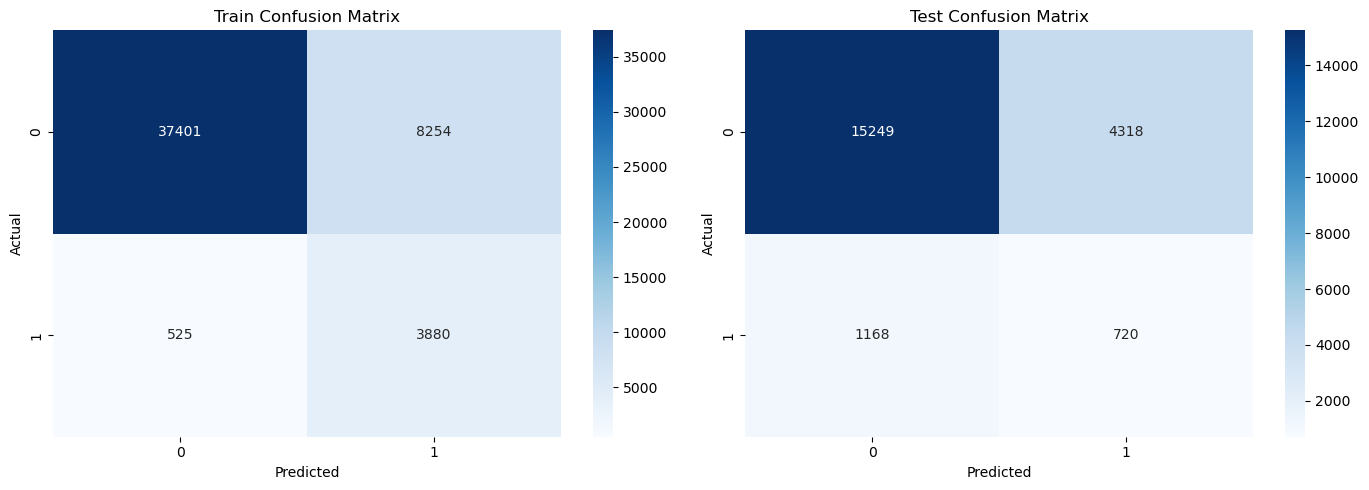

=== ROC AUC Curve ===


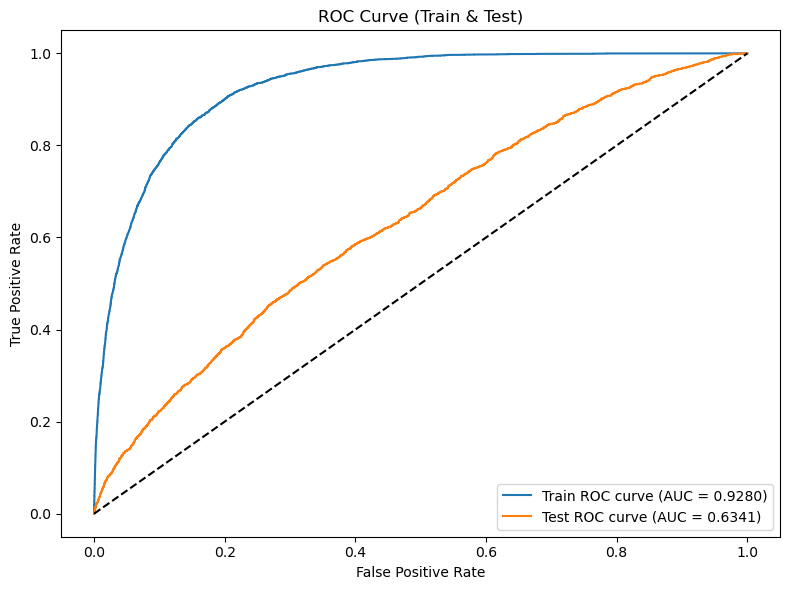

In [10]:
mp.evaluate_model(y_test, y_pred, y_proba, y_train, y_pred_train, y_proba_train)

1440 fits takes more than 42 min, interrupted, do not try again.

160 fits takes 3+ min.

90 fits takes 1+ min.

In [11]:
%%time

param_grid = {
    "n_estimators": [300, 500],
    # "max_depth": [10, 15, 20],
    "reg_alpha": [20, 30, 40],
    "reg_lambda": [20, 30, 40],
}

xgb_base = make_balanced_xgb()

grid_search = GridSearchCV(estimator=xgb_base, param_grid=param_grid, scoring="f1", cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
CPU times: total: 13.9 s
Wall time: 1min 8s


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'n_estimators': [300, 500], 'reg_alpha': [20, 30, ...], 'reg_lambda': [20, 30, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [12]:
best_xgb = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

y_pred_best = best_xgb.predict(X_test)
y_pred_train_best = best_xgb.predict(X_train)
y_proba_best = best_xgb.predict_proba(X_test)
y_proba_train_best = best_xgb.predict_proba(X_train)

print("Accuracy (train):", accuracy_score(y_train, y_pred_train_best))
print("Accuracy (test):", accuracy_score(y_test, y_pred_best))
print(f"AUC ROC (train): {auc(*roc_curve(y_train, y_proba_train_best[:, 1])[:2]):.6f}")
print(f"AUC ROC (test): {auc(*roc_curve(y_test, y_proba_best[:, 1])[:2]):.6f}")
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Best Parameters: {'n_estimators': 300, 'reg_alpha': 40, 'reg_lambda': 20}
Accuracy (train): 0.8427886536156612
Accuracy (test): 0.7592635749242601
AUC ROC (train): 0.941320
AUC ROC (test): 0.633098
[[15616  3951]
 [ 1214   674]]
              precision    recall  f1-score   support

           0       0.93      0.80      0.86     19567
           1       0.15      0.36      0.21      1888

    accuracy                           0.76     21455
   macro avg       0.54      0.58      0.53     21455
weighted avg       0.86      0.76      0.80     21455



Not ideal, but we can work on this

In [13]:
def make_balanced_xgb2(**kwargs) -> XGBClassifier:
    return XGBClassifier(random_state=42, scale_pos_weight=pos_weight, enable_categorical=True, n_estimators=300, reg_alpha=40, reg_lambda=20, verbosity=1, **kwargs)

In [14]:
def get_top_features(xgb: XGBClassifier) -> list[tuple[str, str]]:
    return sorted(xgb.get_booster().get_score(importance_type="gain").items(), key=lambda t: t[1], reverse=True)

get_top_features(best_xgb)

[('discharge_disposition_id', 16.446420669555664),
 ('number_inpatient', 14.822281837463379),
 ('diag_1', 7.159003734588623),
 ('diabetesMed', 6.288259029388428),
 ('age', 5.699714183807373),
 ('diag_2', 5.418658256530762),
 ('number_emergency', 5.109860897064209),
 ('diag_3', 4.895535469055176),
 ('change', 4.873386383056641),
 ('insulin', 4.864062309265137),
 ('number_diagnoses', 4.863610744476318),
 ('time_in_hospital', 4.815948963165283),
 ('gender', 4.801751136779785),
 ('num_procedures', 4.739653587341309),
 ('metformin', 4.721370697021484),
 ('admission_type_id', 4.453357696533203),
 ('A1Cresult', 4.450669288635254),
 ('rosiglitazone', 4.389516830444336),
 ('glimepiride', 4.374966144561768),
 ('num_medications', 4.328483581542969),
 ('race', 4.2383527755737305),
 ('num_lab_procedures', 4.213868618011475),
 ('max_glu_serum', 4.056097507476807),
 ('number_outpatient', 3.9897305965423584),
 ('glipizide', 3.985379219055176),
 ('glyburide', 3.9540998935699463),
 ('pioglitazone', 3.95

## (5-)Stepwise reduction from top 20 predictors

In [15]:
xgbs2 = {}
old_xgb = best_xgb
for n in [20, 15, 10, 5]:
    topn_features = [x for x, _ in get_top_features(old_xgb)[:n]]
    print(f"Top {n}: {topn_features}")
    X_train2 = X_train[topn_features]
    X_test2 = X_test[topn_features]
    xgb = make_balanced_xgb2()
    xgb.fit(X_train2, y_train)
    y_pred = xgb.predict(X_test2)
    y_proba = xgb.predict_proba(X_test2)
    y_pred_train = xgb.predict(X_train2)
    y_proba_train = xgb.predict_proba(X_train2)
    print(f"\033[31mXGBoost train accuracy: {accuracy_score(y_train, y_pred_train):.6f}\033[0m")
    print(f"\033[33mXGBoost test accuracy: {accuracy_score(y_test, y_pred):.6f}\033[0m")
    print(f"\033[31mXGBoost train AUC ROC: {auc(*roc_curve(y_train, y_proba_train[:, 1])[:2]):.6f}\033[0m")
    print(f"\033[32mXGBoost test AUC ROC: {auc(*roc_curve(y_test, y_proba[:, 1])[:2]):.6f}\033[0m")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    xgbs2[n] = xgb
    old_xgb = xgb
    print()

Top 20: ['discharge_disposition_id', 'number_inpatient', 'diag_1', 'diabetesMed', 'age', 'diag_2', 'number_emergency', 'diag_3', 'change', 'insulin', 'number_diagnoses', 'time_in_hospital', 'gender', 'num_procedures', 'metformin', 'admission_type_id', 'A1Cresult', 'rosiglitazone', 'glimepiride', 'num_medications']
XGBoost train accuracy: 0.793488
XGBoost test accuracy: 0.725006
XGBoost train AUC ROC: 0.894552
XGBoost test AUC ROC: 0.636962
[[14748  4819]
 [ 1081   807]]
              precision    recall  f1-score   support

           0       0.93      0.75      0.83     19567
           1       0.14      0.43      0.21      1888

    accuracy                           0.73     21455
   macro avg       0.54      0.59      0.52     21455
weighted avg       0.86      0.73      0.78     21455


Top 15: ['discharge_disposition_id', 'number_inpatient', 'diabetesMed', 'diag_1', 'age', 'gender', 'diag_2', 'time_in_hospital', 'number_emergency', 'diag_3', 'insulin', 'number_diagnoses', 'num_pr

### XGBoost, balanced, top 5 predictors, n_estimators = 300, alpha = 40, lambda = 20, AUC = 0.655

=== Train Set Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.67      0.78     45655
           1       0.14      0.58      0.23      4405

    accuracy                           0.66     50060
   macro avg       0.54      0.62      0.51     50060
weighted avg       0.87      0.66      0.73     50060

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.67      0.78     19567
           1       0.14      0.55      0.22      1888

    accuracy                           0.66     21455
   macro avg       0.54      0.61      0.50     21455
weighted avg       0.87      0.66      0.73     21455

=== Train Metrics ===
Accuracy: 0.6593, Precision: 0.8719, Recall: 0.6593, F1-score: 0.7327, ROC AUC: 0.6745
=== Test Metrics ===
Accuracy: 0.6602, Precision: 0.8687, Recall: 0.6602, F1-score: 0.7333, ROC AUC: 0.6547
=== Confusion Matrix ===


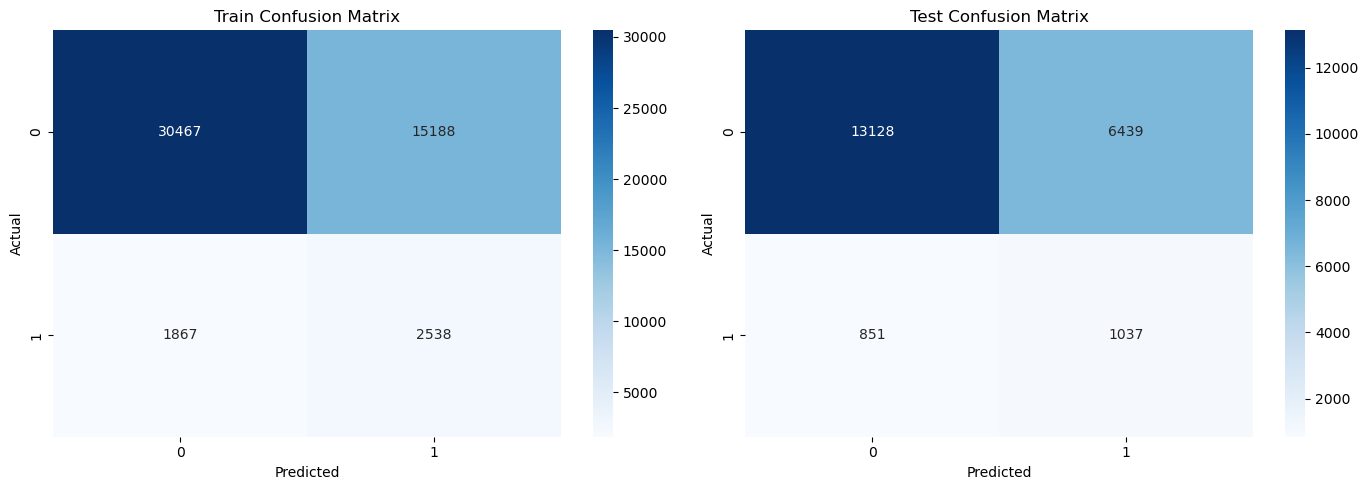

=== ROC AUC Curve ===


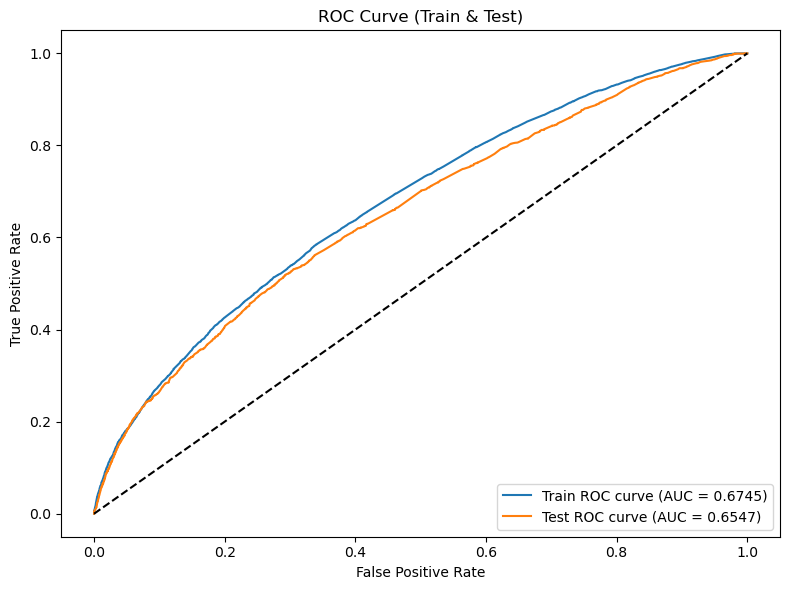

In [16]:
mp.evaluate_model(y_test, y_pred, y_proba, y_train, y_pred_train, y_proba_train)